In [2]:
import xarray as xr
import seaborn as sns
import warnings
import numpy as np
import scipy.stats as stats
from scipy.stats import pearsonr
from scipy.stats import gamma, norm
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import glob
import datetime
import matplotlib.pyplot as plt
import pickle
import cartopy.crs as ccrs
from sklearn.preprocessing import QuantileTransformer
import cartopy.feature as cfeature
from scipy.stats import spearmanr
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
import seaborn as sns
import os
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from sklearn.metrics import silhouette_score
from scipy.stats import pearsonr
from pathlib import Path
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
pd.options.mode.chained_assignment = None
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

#### reading in buoyancy

In [3]:
with open('/home/annierosen16/master.pkl', 'rb') as f:
    
    master = pickle.load(f)
    
master['month'] = master['date'].dt.month

master['year'] = master['date'].dt.year

In [7]:
# drought & wet year selection

_2007 = master[(master['year'].isin([2007]))]

_2011 = master[(master['year'].isin([2011]))]

# rainfall groups for all years 

trace_rainfall = master[(master['total_rainfall'] < 0.1)]

low_rainfall = master[(master['total_rainfall'] > 0.1) & (master['total_rainfall'] < 2.5)]

med_rainfall = master[(master['total_rainfall'] > 2.5) & (master['total_rainfall'] < 10)]

heavy_rainfall = master[(master['total_rainfall'] > 10) & (master['total_rainfall'])]

# 2011 

trace_rainfall_2011 = master[(master["year"] == 2011) & (master["total_rainfall"] < 0.1)]

low_rainfall_2011 = master[(master["year"] == 2011) & (master["total_rainfall"] > 0.1) & (master["total_rainfall"] < 2.5)]

med_rainfall_2011 = master[(master["year"] == 2011) & (master["total_rainfall"] > 2.5) & (master["total_rainfall"] < 10)]

heavy_rainfall_2011 = master[(master["year"] == 2011) & (master["total_rainfall"] > 10)]


# 2007

trace_rainfall_2007 = master[(master["year"] == 2007) & (master["total_rainfall"] < 0.1)]

low_rainfall_2007 = master[(master["year"] == 2007) & (master["total_rainfall"] > 0.1) & (master["total_rainfall"] < 2.5)]

med_rainfall_2007 = master[(master["year"] == 2007) & (master["total_rainfall"] > 2.5) & (master["total_rainfall"] < 10)]

heavy_rainfall_2007 = master[(master["year"] == 2007) & (master["total_rainfall"] > 10)]

In [8]:
# gridpoint average blc and blt standardized anomaly for drought & wet year and rainfall groups

# for drought and wet year 

_2007_grouped = _2007.groupby(["latitude", "longitude"], as_index=False)[['blc_stnd_anom', 'blt_stnd_anom']].mean()

_2011_grouped = _2011.groupby(["latitude", "longitude"], as_index=False)[['blc_stnd_anom', 'blt_stnd_anom']].mean()

# for all rainfall groups 

trace_rainfall_grouped = trace_rainfall.groupby(["latitude", "longitude"], as_index=False)[['blc_stnd_anom', 'blt_stnd_anom']].mean()

low_rainfall_grouped = low_rainfall.groupby(["latitude", "longitude"], as_index=False)[['blc_stnd_anom', 'blt_stnd_anom']].mean()

med_rainfall_grouped = med_rainfall.groupby(["latitude", "longitude"], as_index=False)[['blc_stnd_anom', 'blt_stnd_anom']].mean()

heavy_rainfall_grouped = heavy_rainfall.groupby(["latitude", "longitude"], as_index=False)[['blc_stnd_anom', 'blt_stnd_anom']].mean()

# 2011

trace_rainfall_grouped_2011 = trace_rainfall_2011.groupby(["latitude", "longitude"], as_index=False)[["blc_stnd_anom", "blt_stnd_anom"]].mean()

low_rainfall_grouped_2011 = low_rainfall_2011.groupby(["latitude", "longitude"], as_index=False)[["blc_stnd_anom", "blt_stnd_anom"]].mean()

med_rainfall_grouped_2011 = med_rainfall_2011.groupby(["latitude", "longitude"], as_index=False)[["blc_stnd_anom", "blt_stnd_anom"]].mean()

heavy_rainfall_grouped_2011 = heavy_rainfall_2011.groupby(["latitude", "longitude"], as_index=False)[["blc_stnd_anom", "blt_stnd_anom"]].mean()

# 2007 

trace_rainfall_grouped_2007 = trace_rainfall_2007.groupby(["latitude", "longitude"], as_index=False)[["blc_stnd_anom", "blt_stnd_anom"]].mean()

low_rainfall_grouped_2007 = low_rainfall_2007.groupby(["latitude", "longitude"], as_index=False)[["blc_stnd_anom", "blt_stnd_anom"]].mean()

med_rainfall_grouped_2007 = med_rainfall_2007.groupby(["latitude", "longitude"], as_index=False)[["blc_stnd_anom", "blt_stnd_anom"]].mean()

heavy_rainfall_grouped_2007 = heavy_rainfall_2007.groupby(["latitude", "longitude"], as_index=False)[["blc_stnd_anom", "blt_stnd_anom"]].mean()

#### figure -> joint frequency distributions for drought vs. wet year average BLC/BLT anomalies

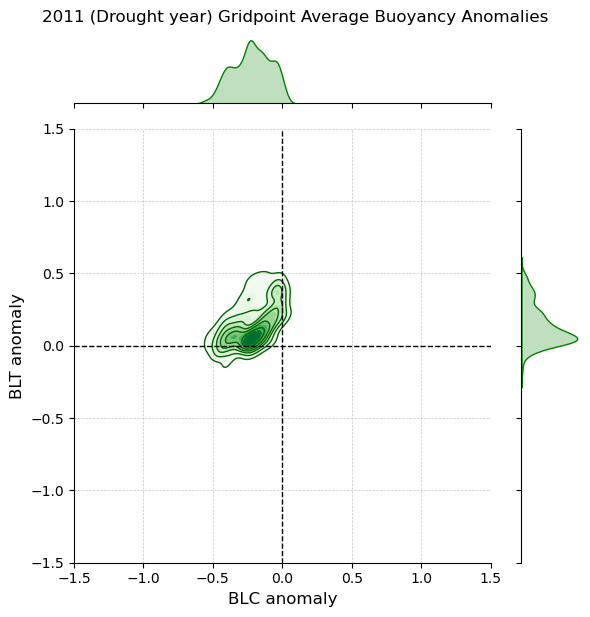

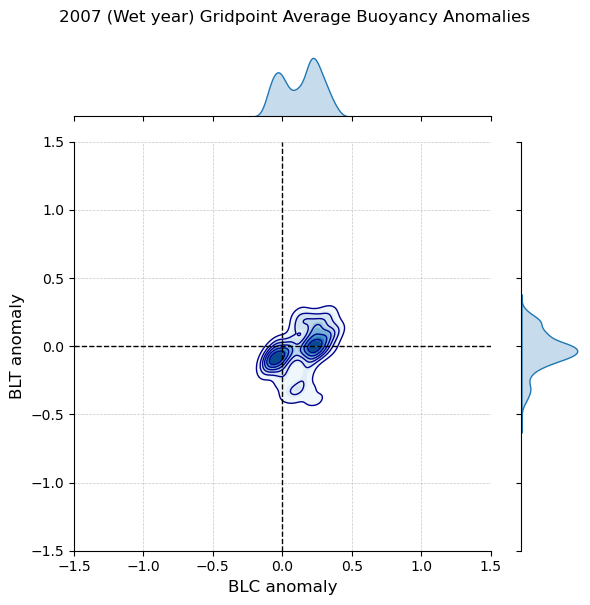

In [9]:
## _2011_grouped TERCILE BELOW 

g = sns.JointGrid(
    
    x=_2011_grouped['blc_stnd_anom'],
    
    y=_2011_grouped['blt_stnd_anom'],
)


sns.kdeplot(
    
    x=_2011_grouped['blc_stnd_anom'],
    
    y=_2011_grouped['blt_stnd_anom'],
    
    cmap="Greens",
    
    fill=True,
    
    ax=g.ax_joint, 

)

# filled density

sns.kdeplot(
    
    x=_2011_grouped['blc_stnd_anom'],
    
    y=_2011_grouped['blt_stnd_anom'],
    
    cmap="Greens",
    
    fill=True,
    
    ax=g.ax_joint,
    
    alpha=0.7
)

sns.kdeplot(
    
    x=_2011_grouped['blc_stnd_anom'],
    
    y=_2011_grouped['blt_stnd_anom'],
    
    color="darkgreen",
    
    linewidths=1,
    
    levels=7,
    
    ax=g.ax_joint
)


ax_lim = 1.5

# Marginals

sns.kdeplot(x=_2011_grouped['blc_stnd_anom'], fill=True, ax=g.ax_marg_x, color='green')

sns.kdeplot(y=_2011_grouped['blt_stnd_anom'], fill=True, ax=g.ax_marg_y, color='green')

# Add 0 lines to the joint plot

g.ax_joint.axhline(0, color="k", linestyle="--", linewidth=1)

g.ax_joint.axvline(0, color="k", linestyle="--", linewidth=1)

# Axis labels

g.set_axis_labels("BLC anomaly", "BLT anomaly", fontsize=12)

# Set x and y limits on the joint axis

g.ax_joint.set_xlim(-ax_lim, ax_lim)

g.ax_joint.set_ylim(-ax_lim, ax_lim)

plt.tight_layout()

g.ax_joint.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.suptitle("2011 (Drought year) Gridpoint Average Buoyancy Anomalies", ha='center', va='top', y=1.02, fontsize=12)

plt.show()


g = sns.JointGrid(
    
    x=_2007_grouped['blc_stnd_anom'],
    
    y=_2007_grouped['blt_stnd_anom'],
)

# Joint KDE

sns.kdeplot(
    
    x=_2007_grouped['blc_stnd_anom'],
    
    y=_2007_grouped['blt_stnd_anom'],
    
    cmap="Blues",
    
    ax=g.ax_joint, 
    
    fill=True
)

# filled density

sns.kdeplot(
    
    x=_2007_grouped['blc_stnd_anom'],
    
    y=_2007_grouped['blt_stnd_anom'],
    
    cmap="Blues",
    
    fill=True,
    
    ax=g.ax_joint,
    
    alpha=0.7
)

# Contour lines
sns.kdeplot(
    
    x=_2007_grouped['blc_stnd_anom'],
    
    y=_2007_grouped['blt_stnd_anom'],
    
    color="darkblue",
    
    linewidths=1,
    
    levels=7,       # number of contour lines
    
    ax=g.ax_joint
)

# Marginals

sns.kdeplot(x=_2007_grouped['blc_stnd_anom'], fill=True, ax=g.ax_marg_x)

sns.kdeplot(y=_2007_grouped['blt_stnd_anom'], fill=True, ax=g.ax_marg_y)

# Add 0 lines to the joint plot

g.ax_joint.axhline(0, color="k", linestyle="--", linewidth=1)

g.ax_joint.axvline(0, color="k", linestyle="--", linewidth=1)

g.ax_joint.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Axis labels

g.set_axis_labels("BLC anomaly", "BLT anomaly", fontsize=12)

plt.suptitle("2007 (Wet year) Gridpoint Average Buoyancy Anomalies", ha='center', va='top', y=1, fontsize=12)

g.ax_joint.set_xlim(-ax_lim, ax_lim)

g.ax_joint.set_ylim(-ax_lim, ax_lim)

plt.tight_layout()

plt.show()

#### figure -> joint frequency distributions for rainfall groups over all years

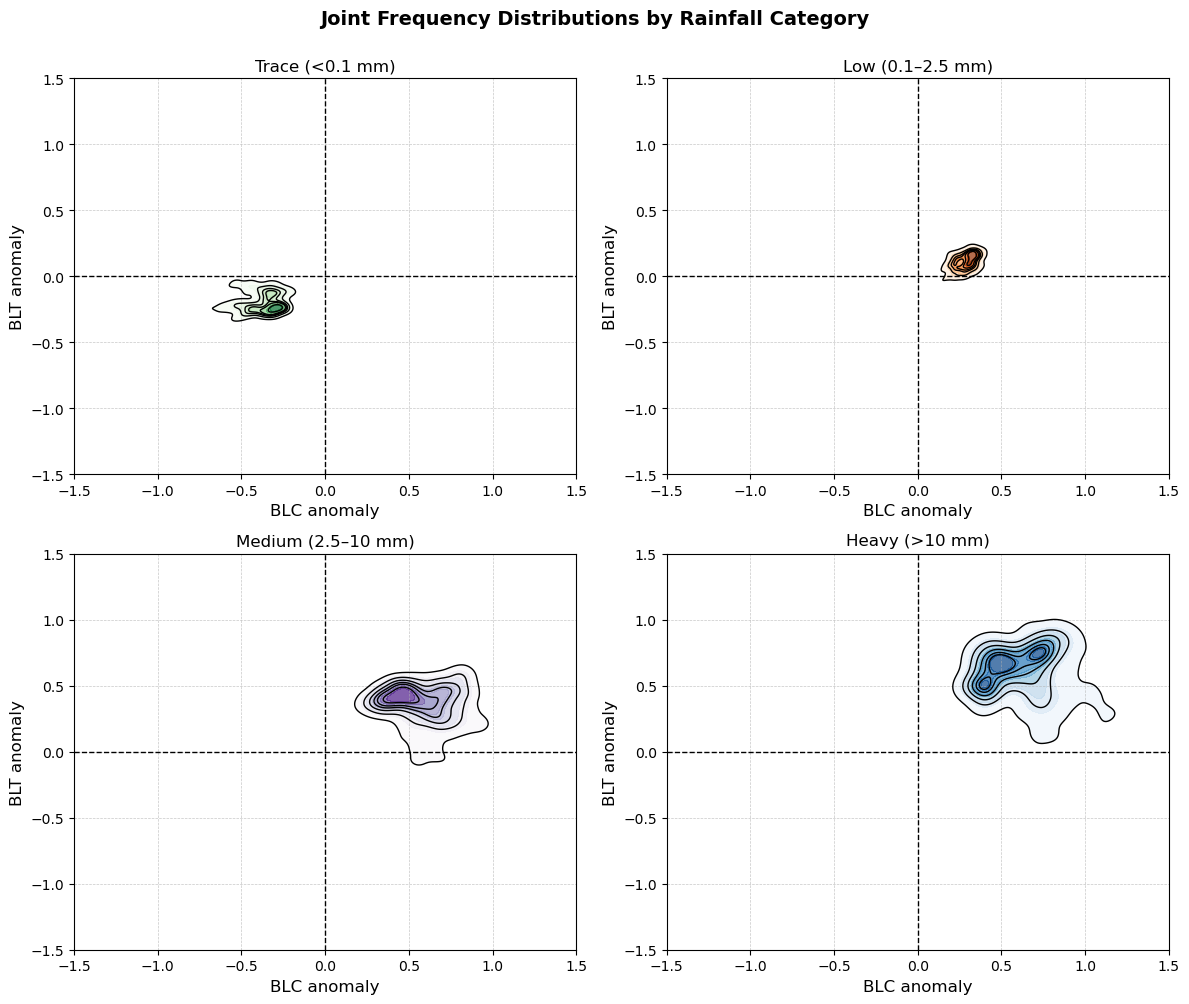

In [10]:
rain_groups = {
    
    "Trace (<0.1 mm)": trace_rainfall_grouped,
    
    "Low (0.1–2.5 mm)": low_rainfall_grouped,
    
    "Medium (2.5–10 mm)": med_rainfall_grouped,
    
    "Heavy (>10 mm)": heavy_rainfall_grouped
}

colors = {
    
    "Trace (<0.1 mm)": "Greens",
    
    "Low (0.1–2.5 mm)": "Oranges",
    
    "Medium (2.5–10 mm)": "Purples",
    
    "Heavy (>10 mm)": "Blues"
}

ax_lim = 1.5

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for ax, (title, df) in zip(axes, rain_groups.items()):
    
    sns.kdeplot(
        
        x=df['blc_stnd_anom'],
        
        y=df['blt_stnd_anom'],
        
        cmap=colors[title],
        
        fill=True,
        
        alpha=0.7,
        
        ax=ax
    )

    sns.kdeplot(
        
        x=df['blc_stnd_anom'],
        
        y=df['blt_stnd_anom'],
        
        color="black",
        
        linewidths=1,
        
        levels=7,
        
        ax=ax
    )

    ax.axhline(0, color="k", linestyle="--", linewidth=1)
    
    ax.axvline(0, color="k", linestyle="--", linewidth=1)

    ax.set_xlim(-ax_lim, ax_lim)
    
    ax.set_ylim(-ax_lim, ax_lim)
    
    ax.set_title(title, fontsize=12)
    
    ax.set_xlabel("BLC anomaly", fontsize=12)
    
    ax.set_ylabel("BLT anomaly", fontsize=12)
    
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    
    g.ax_joint.tick_params(axis='both', which='major', labelsize=12)  # joint plot
    
    g.ax_marg_x.tick_params(axis='x', which='major', labelsize=12)    # top marginal
    
    g.ax_marg_y.tick_params(axis='y', which='major', labelsize=12)    # right marginal

fig.suptitle("Joint Frequency Distributions by Rainfall Category", fontsize=14, y=1, fontweight='bold')

plt.tight_layout()

plt.show()

#### creating column for rainfall groups within master to separate by year

In [40]:
def categorize_rainfall(mm):
    
    if mm < 0.1:
        
        return "trace"          # no rainfall
    
    elif 0 < mm <= 2.5:
        
        return "low"            # light precipitation
    
    elif 2.5 < mm <= 10:
        
        return "medium"         # moderate precipitation
    
    else:
        
        return "heavy"          # heavy precipitation

master["rainfall_group"] = master["total_rainfall"].apply(categorize_rainfall)

#### figure -> counts of rainfall groups per year 

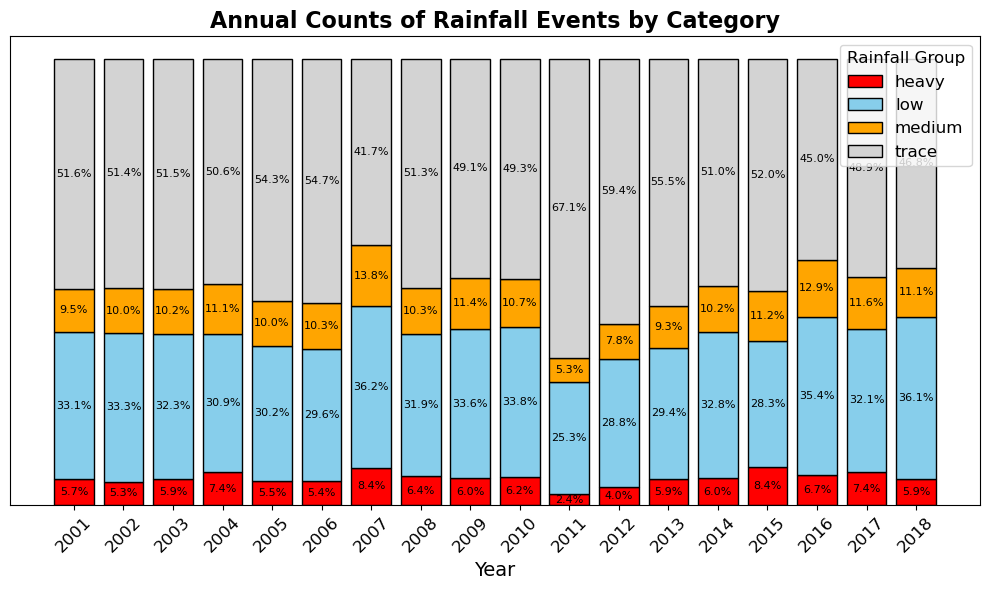

In [41]:
rain_counts = (master.groupby(["year", "rainfall_group"]).size().reset_index(name="count"))

rain_counts_pivot = rain_counts.pivot(index="year", columns="rainfall_group", values="count").fillna(0)

colors = {
    
    "trace": "lightgray",
    
    "low": "skyblue",
    
    "medium": "orange",
    
    "heavy": "red"
}

totals = rain_counts_pivot.sum(axis=1)

percents = rain_counts_pivot.div(totals, axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(rain_counts_pivot))  # numeric array

for cat in rain_counts_pivot.columns:
    
    values = rain_counts_pivot[cat].values
    
    pct = percents[cat].values
    
    bars = ax.bar(
        
        rain_counts_pivot.index,
        
        values,
        
        bottom=bottom,
        
        color=colors[cat],
        
        label=cat,
        
        edgecolor="black"
    )
    
    for i, (val, p) in enumerate(zip(values, pct)):
        
        if val > 0:
            
            ax.text(
                
                rain_counts_pivot.index[i],
                
                bottom[i] + val / 2,
                
                f"{p:.1f}%",
                
                ha="center",
                
                va="center",
                
                fontsize=8
            )
    
    bottom += values

ax.set_xlabel("Year", fontsize=14)

ax.set_title("Annual Counts of Rainfall Events by Category", fontsize=16, weight="bold")

ax.yaxis.set_visible(False)

ax.set_xticks(rain_counts_pivot.index)

ax.tick_params(axis="x", labelrotation=45, labelsize=12)

ax.legend(title="Rainfall Group", fontsize=12, title_fontsize=12)

plt.tight_layout()

plt.show()

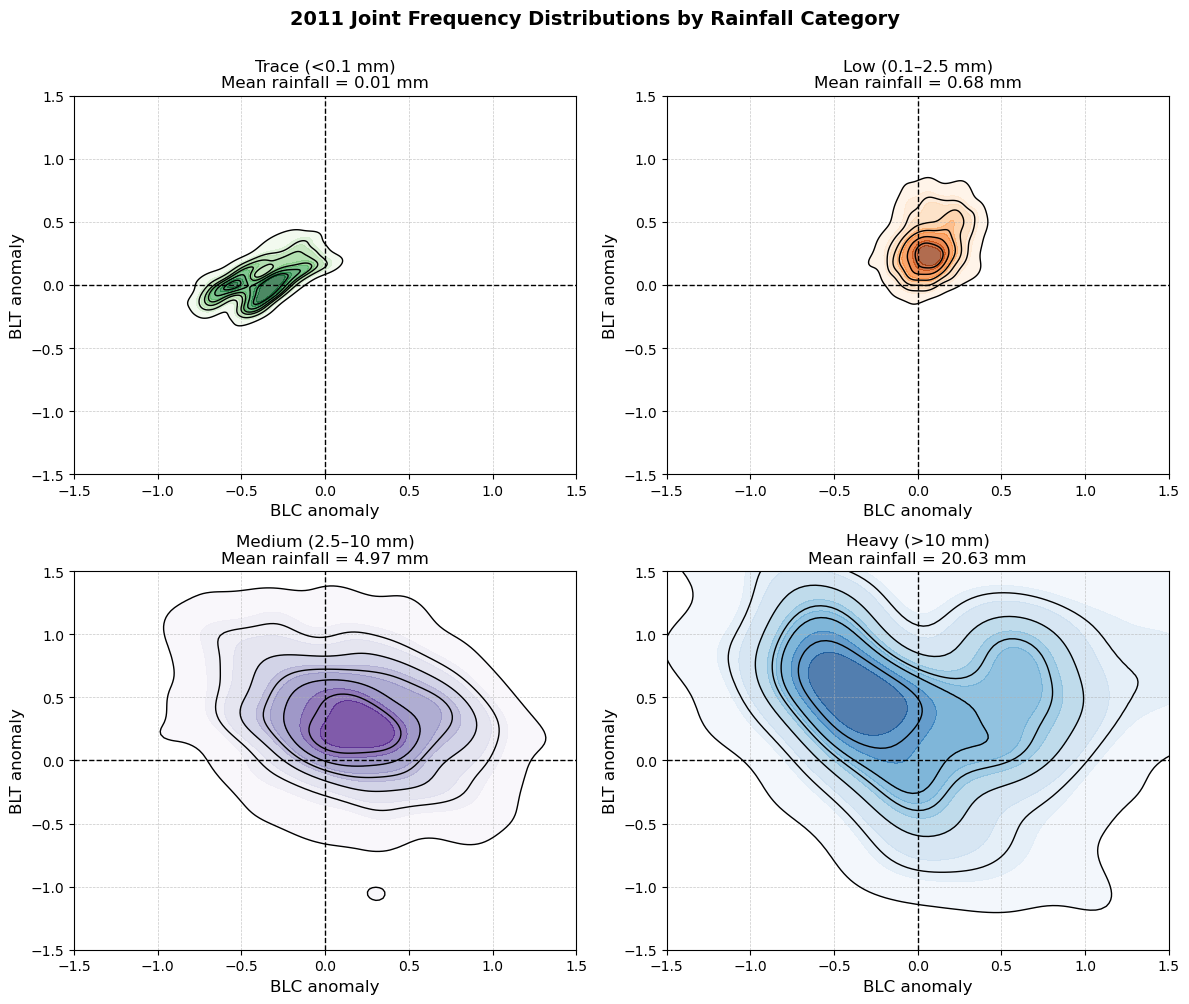

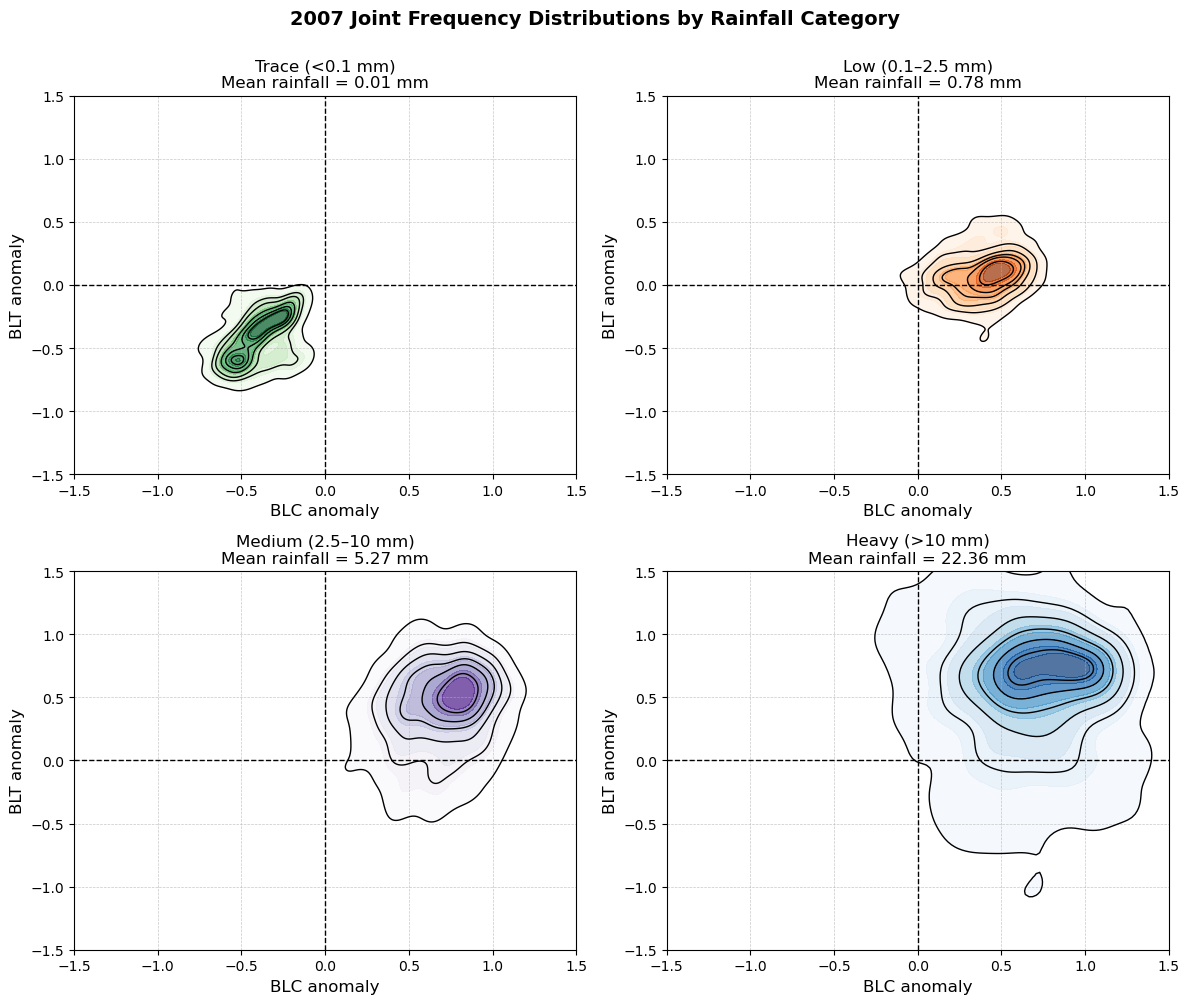

In [51]:
# --- Rainfall group means ---

_2011_rainfall_group_means = (
    master[master['year'] == 2011]
    .groupby('rainfall_group', as_index=False)[['total_rainfall']]
    .mean()
)

_2007_rainfall_group_means = (
    master[master['year'] == 2007]
    .groupby('rainfall_group', as_index=False)[['total_rainfall']]
    .mean()
)

_2011_rainfall_group_means['rainfall_group'] = _2011_rainfall_group_means['rainfall_group'].replace({
    "trace": "Trace (<0.1 mm)",
    "low": "Low (0.1–2.5 mm)",
    "medium": "Medium (2.5–10 mm)",
    "heavy": "Heavy (>10 mm)"
})

_2007_rainfall_group_means['rainfall_group'] = _2007_rainfall_group_means['rainfall_group'].replace({
    "trace": "Trace (<0.1 mm)",
    "low": "Low (0.1–2.5 mm)",
    "medium": "Medium (2.5–10 mm)",
    "heavy": "Heavy (>10 mm)"
})



colors = {
    
    "Trace (<0.1 mm)": "Greens",
    
    "Low (0.1–2.5 mm)": "Oranges",
    
    "Medium (2.5–10 mm)": "Purples",
    
    "Heavy (>10 mm)": "Blues"
}


ax_lim = 1.5


def plot_rainfall_groups(rain_groups, year, group_means):
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    axes = axes.flatten()
    
    for ax, (title, df) in zip(axes, rain_groups.items()):
        
        # Extract mean rainfall for this group
        mean_rain = group_means.loc[group_means['rainfall_group'] == title, 'total_rainfall'].values[0]
        
        # Filled KDE
        sns.kdeplot(
            x=df['blc_stnd_anom'],
            y=df['blt_stnd_anom'],
            cmap=colors[title],
            fill=True,
            alpha=0.7,
            ax=ax
        )
        
        # Contour lines
        sns.kdeplot(
            x=df['blc_stnd_anom'],
            y=df['blt_stnd_anom'],
            color="black",
            linewidths=1,
            levels=7,
            ax=ax
        )
        
        # Zero lines
        ax.axhline(0, color="k", linestyle="--", linewidth=1)
        
        ax.axvline(0, color="k", linestyle="--", linewidth=1)
        
        # Axis limits
        ax.set_xlim(-ax_lim, ax_lim)
        
        ax.set_ylim(-ax_lim, ax_lim)
        
        # Set title with mean rainfall
        ax.set_title(f"{title}\nMean rainfall = {mean_rain:.2f} mm", fontsize=12)
        
        ax.set_xlabel("BLC anomaly", fontsize=12)
        
        ax.set_ylabel("BLT anomaly", fontsize=12)
        
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    
    fig.suptitle(f"{year} Joint Frequency Distributions by Rainfall Category",
        
                 fontsize=14, y=1, fontweight='bold')
    
    plt.tight_layout()
    
    plt.show()


# --- Year-specific dictionaries ---
rain_groups_2011 = {
    
    "Trace (<0.1 mm)": trace_rainfall_grouped_2011,
    
    "Low (0.1–2.5 mm)": low_rainfall_grouped_2011,
    
    "Medium (2.5–10 mm)": med_rainfall_grouped_2011,
    
    "Heavy (>10 mm)": heavy_rainfall_grouped_2011
}


rain_groups_2007 = {
    
    "Trace (<0.1 mm)": trace_rainfall_grouped_2007,
    
    "Low (0.1–2.5 mm)": low_rainfall_grouped_2007,
    
    "Medium (2.5–10 mm)": med_rainfall_grouped_2007,
    
    "Heavy (>10 mm)": heavy_rainfall_grouped_2007
}


# --- Plot ---

plot_rainfall_groups(rain_groups_2011, 2011, _2011_rainfall_group_means)

plot_rainfall_groups(rain_groups_2007, 2007, _2007_rainfall_group_means)
